In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()
print(iris)
print(iris.feature_names)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [4]:
print(iris.target_names)
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = iris.target
df.head()

['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df['species'] = df['species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [6]:
print(df.shape)

(150, 5)


In [7]:
print(df['species'].value_counts())

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


In [8]:
avg_sepal = df.groupby('species')['sepal length (cm)'].mean()

print(avg_sepal)

species
Setosa        5.006
Versicolor    5.936
Virginica     6.588
Name: sepal length (cm), dtype: float64


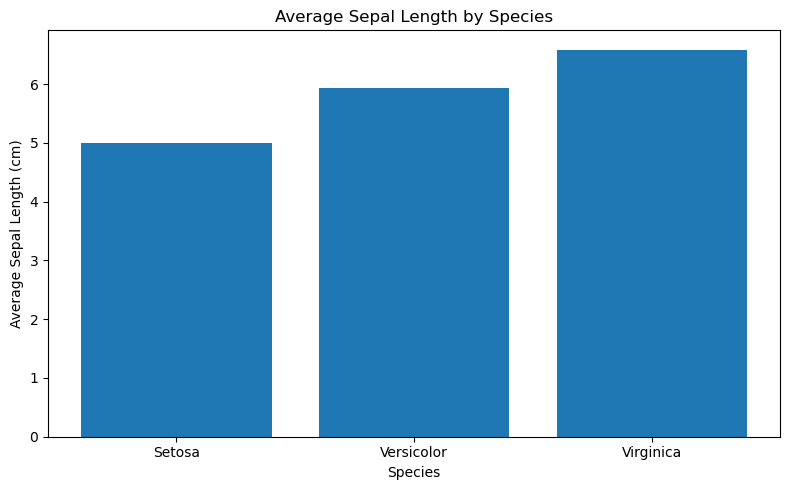

In [9]:
plt.figure(figsize=(8, 5))

plt.bar(avg_sepal.index, avg_sepal.values)

plt.title('Average Sepal Length by Species')
plt.xlabel('Species')
plt.ylabel('Average Sepal Length (cm)')

plt.tight_layout()
plt.show()

Takeaway: Virginica has the highest average sepal length, while Setosa has the lowest.

In [10]:
avg_petal = df.groupby('species')['petal length (cm)'].mean()

print(avg_petal)

species
Setosa        1.462
Versicolor    4.260
Virginica     5.552
Name: petal length (cm), dtype: float64


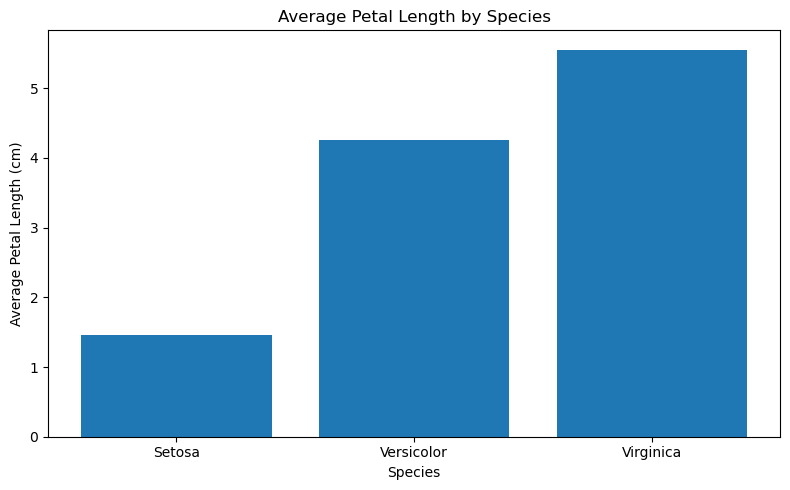

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(avg_petal.index, avg_petal.values)

plt.title('Average Petal Length by Species')
plt.xlabel('Species')
plt.ylabel('Average Petal Length (cm)')

plt.tight_layout()
plt.show()

Takeaway: Virginica has the longest average petals, followed by Versicolor, while Setosa has substantially shorter petals.

In [12]:
avg_measurements = df.groupby('species')[
    ['sepal length (cm)', 'sepal width (cm)',
     'petal length (cm)', 'petal width (cm)']
].mean()

print(avg_measurements)

            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
Setosa                  5.006             3.428              1.462   
Versicolor              5.936             2.770              4.260   
Virginica               6.588             2.974              5.552   

            petal width (cm)  
species                       
Setosa                 0.246  
Versicolor             1.326  
Virginica              2.026  


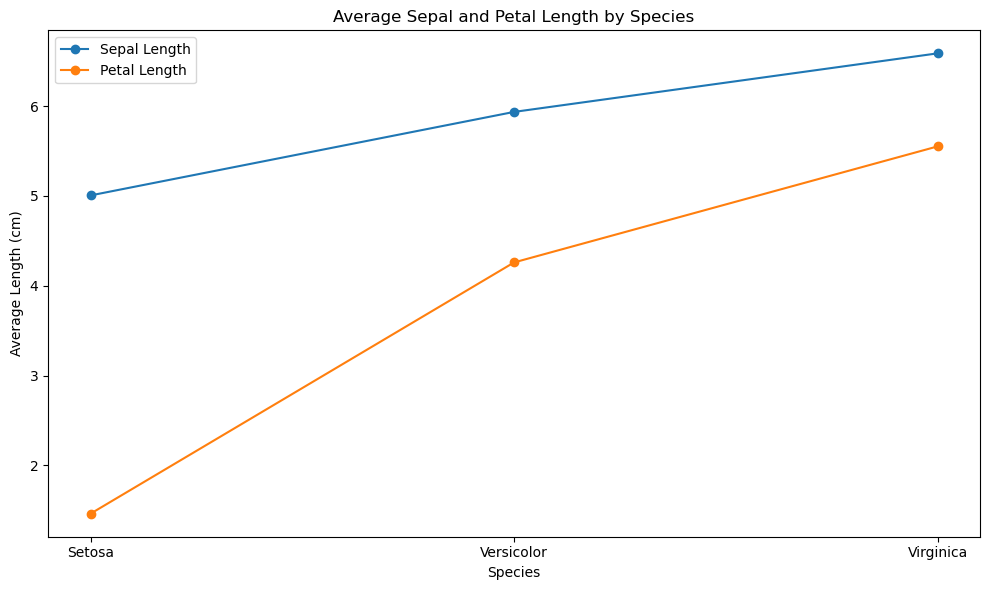

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    avg_measurements.index,
    avg_measurements['sepal length (cm)'],
    marker='o',
    label='Sepal Length'
)

plt.plot(
    avg_measurements.index,
    avg_measurements['petal length (cm)'],
    marker='o',
    label='Petal Length'
)

plt.title('Average Sepal and Petal Length by Species')
plt.xlabel('Species')
plt.ylabel('Average Length (cm)')
plt.legend()

plt.tight_layout()
plt.show()

Takeaway: Petal and sepal lengths generally increase from Setosa to Virginica, with Virginica showing the largest measurements.

In [14]:
species_count = df['species'].value_counts()

print(species_count)

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


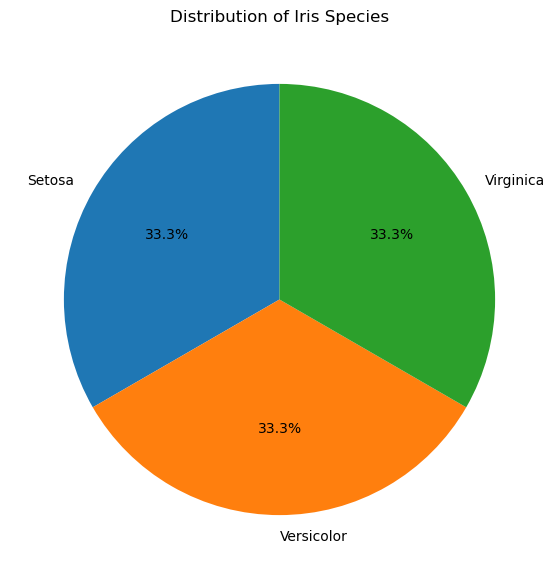

In [15]:
plt.figure(figsize=(7, 7))

plt.pie(
    species_count.values,
    labels=species_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Iris Species')

plt.show()

Takeaway: The dataset is evenly distributed, with each species representing approximately one-third of the observations.

**Data Story**

The Iris dataset contains three equally represented species: Setosa, Versicolor, and Virginica. The analysis shows a clear increase in average sepal and petal measurements from Setosa to Virginica. Virginica has the largest average sepal and petal lengths, while Setosa has the smallest measurements. The balanced species distribution confirms that the dataset contains an equal number of observations for each species. Overall, petal and sepal measurements provide clear differences between the three Iris species.

**Interview Questions**

Q1. When would you choose a bar chart over a line chart?

Answer:

A bar chart is preferred when comparing values across discrete categories, while a line chart is more appropriate for showing trends or changes across an ordered sequence, especially time.

Q2. Why are pie charts often discouraged in professional reporting?

Answer:

Pie charts make it difficult to accurately compare similar-sized segments, especially when there are many categories. Bar charts usually communicate comparisons more clearly and precisely.